In [1]:
import os 
import numpy as np
import seaborn as sns
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import (average_precision_score, roc_auc_score, roc_curve,
    precision_recall_curve, f1_score, precision_score, recall_score,
    confusion_matrix, accuracy_score)

from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

## Installs the Kaggle command line

This cell allows anyone who is re-running the codes to pull the indentical dataset from Kaggle. 

In [2]:
!pip install kaggle

Defaulting to user installation because normal site-packages is not writeable


## Authentication process

Kaggle requires credentials from users who downloading this dataset with an API token from Kaggle.

In [3]:
!mkdir -p ~/.kaggle && echo KGAT_73d684c216900c7c379ea62ed643572c > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token 

## Further athentication

In [4]:
!python -m kaggle competitions list 

ref                                                                           deadline             category         reward  teamCount  userHasEntered  
----------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge   2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                            2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                    2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection          2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3                  2026-11-02

## Unzip and download the dataset

The dataset was uploaded throught the API as the full dataset failed to transfer through manual uploading. The output successfully pulled 74.7 MB. 

In [5]:
!python -m kaggle datasets download -d salikhussaini49/prediction-of-sepsis -p ./kaggle_download --unzip 

Dataset URL: https://www.kaggle.com/datasets/salikhussaini49/prediction-of-sepsis
License(s): CC-BY-NC-SA-4.0
100%|██████████████████████████████████████| 74.7M/74.7M [00:02<00:00, 36.0MB/s]



## Downloads

A list of downloaded datasets.

In [6]:
for root, dirs, files in os.walk("./kaggle_download"): 
    if files: 
         print(root, "->", len(files), "files") 

./kaggle_download -> 6 files
./kaggle_download/training_setA/training -> 20336 files
./kaggle_download/.ipynb_checkpoints -> 1 files
./kaggle_download/training_setB/training_setB -> 20000 files


## Load training set A

This cell loads and reads all .psv files in training dataset A only, preparing it for analysis.

In [7]:
data_dir = "./kaggle_download/training_setA/training" 
from pathlib import Path 
import pandas as pd 

def read_psv(path, patient_id): 
    df = pd.read_csv(path, sep="|") 
    df["PatientID"] = patient_id 
    return df 

def load_all_patients(data_dir): 
    data_dir = Path(data_dir) 
    frames = [] 

    for f in sorted(data_dir.glob("*.psv")): 

        frames.append(read_psv(f, f.stem)) 

    if not frames: 

        raise FileNotFoundError("No .psv files found — check DATA_DIR.") 

    return pd.concat(frames, ignore_index=True) 
raw = load_all_patients(data_dir) 

print(raw.shape) 
print(raw["PatientID"].nunique(), "patients") 

(790215, 42)
20336 patients


## Inspection

This cells inspects the number of patients in training set A, names the columns and each patients hours spent in ICU and hospital stay.

In [8]:
n_patients = raw["PatientID"].nunique() 

print(f"Rows (hours): {len(raw)}") 
print(f"Patients: {n_patients}") 
print(f"Columns: {list(raw.columns)}") 

Rows (hours): 790215
Patients: 20336
Columns: ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'PatientID']


## Data cleaning

This code cell includes the leakage free cleaning procedure. All duplicate rows are removed and physiologically impossible readings are replaced with 'NaN', missing values within each patient are forward-filled so that only previous readings are carried forward, and `EtCO2` is dropped as 100% of the values are missing. In order to learn the median from the training data, Population median filling was removed and applied after train/test split. 

In [9]:
# Duplicate values removed 

before = len(raw)
df = raw.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate rows")

# Physiologically impossible values 

plausible_ranges = {
    "HR": (20, 300), "O2Sat": (50, 100), "Temp": (25, 45),
    "SBP": (40, 300), "MAP": (20, 250), "DBP": (10, 200),
    "Resp": (4, 60),  "Age": (0, 120),
}
for col, (lo, hi) in plausible_ranges.items():
    if col in df.columns:
        bad = ~df[col].between(lo, hi) & df[col].notna()
        print(f"{col}: {bad.sum()} implausible values set to NaN")
        df.loc[bad, col] = np.nan

# Forward-fill within each patient

df = df.sort_values(["PatientID", "ICULOS"]) if "ICULOS" in df.columns else df.sort_values("PatientID")
value_cols = [c for c in df.columns if c not in ("PatientID", "SepsisLabel")]
df[value_cols] = df.groupby("PatientID")[value_cols].transform(lambda s: s.ffill())

# EtCO2 column removed
if "EtCO2" in df.columns and df["EtCO2"].isna().all():
    print("Dropping EtCO2 — 100% missing")
    df = df.drop(columns=["EtCO2"])

print(f"\nShape after leakage-free cleaning: {df.shape}")
print(f"Remaining missing values (filled after split): {df.isna().sum().sum():,}")

Dropped 0 duplicate rows
HR: 0 implausible values set to NaN
O2Sat: 176 implausible values set to NaN
Temp: 4 implausible values set to NaN
SBP: 59 implausible values set to NaN
MAP: 94 implausible values set to NaN
DBP: 13 implausible values set to NaN
Resp: 224 implausible values set to NaN
Age: 0 implausible values set to NaN
Dropping EtCO2 — 100% missing

Shape after leakage-free cleaning: (790215, 41)
Remaining missing values (filled after split): 9,804,678


## Missing values

This cell calculates the percentage of missing values, an average of positive sepsis patients and houly sepsis rate.

In [10]:
missing_pct = raw.isna().mean().sort_values(ascending=False) * 100 

print("\nMissingness by column (%):") 
print(missing_pct.round(1)) 

row_rate = raw["SepsisLabel"].mean() 

patient_rate = raw.groupby("PatientID")["SepsisLabel"].max().mean() 

print(f"Row-level positive rate: {row_rate:.3%}") 
print(f"Patient-level positive rate: {patient_rate:.3%}") 


Missingness by column (%):
EtCO2               100.0
TroponinI            99.9
Bilirubin_direct     99.9
Fibrinogen           99.2
Bilirubin_total      98.8
Alkalinephos         98.5
AST                  98.5
Lactate              96.6
PTT                  95.2
SaO2                 95.0
Calcium              95.0
Phosphate            95.0
Platelets            93.5
Creatinine           93.4
WBC                  92.5
Magnesium            92.2
HCO3                 91.9
BUN                  91.8
Chloride             91.7
PaCO2                91.2
Hgb                  91.2
BaseExcess           89.6
Potassium            89.1
pH                   88.5
Hct                  88.2
Glucose              87.8
FiO2                 85.8
Temp                 66.2
Unit2                48.9
Unit1                48.9
DBP                  48.1
SBP                  15.2
O2Sat                12.0
MAP                  10.2
Resp                  9.8
HR                    7.7
HospAdmTime           0.0
Gender    

## Visualisation

This code cell is a percentage of the missing data in the categories demographics, laboratory and vital signs. The graph is a visualisation of each variables missing values percentage. Laboratory values are less frequently as they are recorded when the clinician indicates and vital signs are recorded almost every hour. 

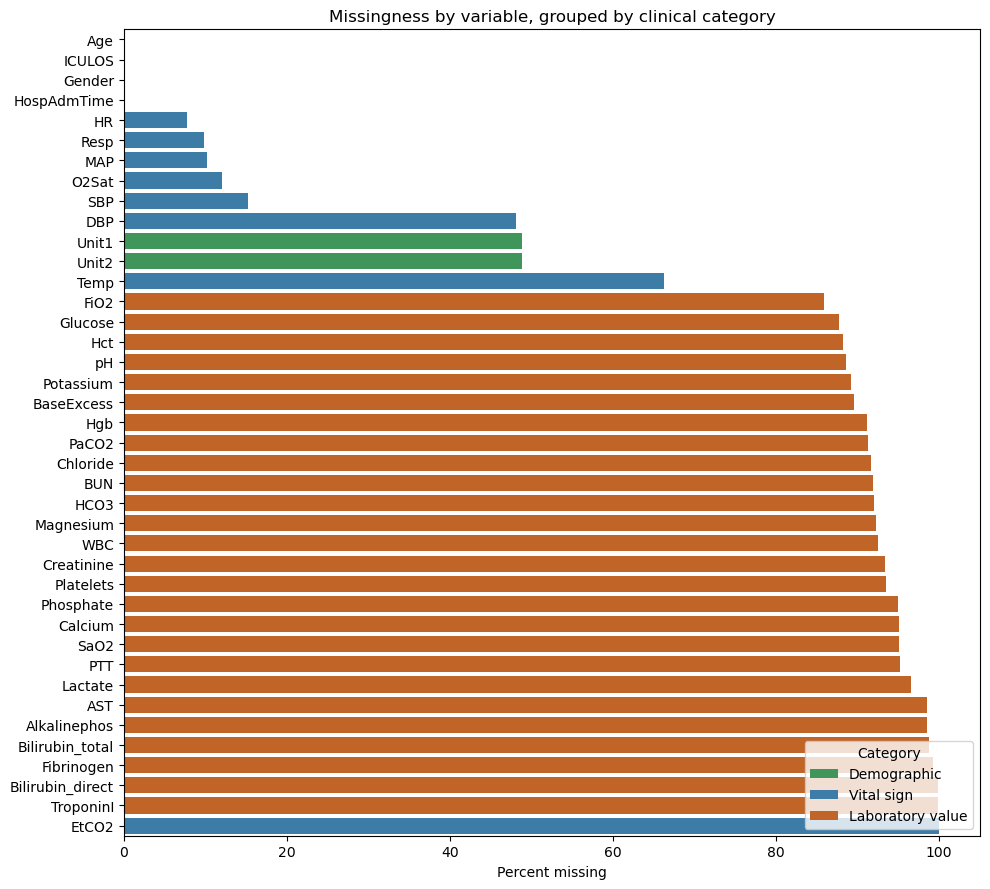

In [11]:
# Categorise vitals, laboratory and demographics

group_map = {}
for c in ["HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp", "EtCO2"]:
    group_map[c] = "Vital sign"
for c in ["Age", "Gender", "Unit1", "Unit2", "HospAdmTime", "ICULOS"]:
    group_map[c] = "Demographic"
    
miss = (raw.isna().mean() * 100).drop(
    labels=[c for c in ["SepsisLabel", "PatientID"] if c in raw.columns],
    errors="ignore",
)
plot_df = (pd.DataFrame({
              "Variable": miss.index,
              "Missing %": miss.values,
              "Group": [group_map.get(c, "Laboratory value") for c in miss.index],
          })
          .sort_values("Missing %"))

plt.figure(figsize=(10, 9))
palette = {"Vital sign": "#2c7fb8", "Laboratory value": "#d95f0e", "Demographic": "#31a354"}
sns.barplot(data=plot_df, y="Variable", x="Missing %", hue="Group",
            palette=palette, dodge=False)
plt.title("Missingness by variable, grouped by clinical category")
plt.xlabel("Percent missing"); plt.ylabel("")
plt.legend(title="Category", loc="lower right")
plt.tight_layout()
plt.show()

## Correlation matrix and mean by class

This code cell compares whether each clincal variable is between the non septic or septic hours. The correlation matrix heatmap plots all variables.

                   No Sepsis      Sepsis  difference
Fibrinogen        309.008628  362.536424   53.527796
AST               190.706627  170.781314  -19.925313
Platelets         211.050089  218.886802    7.836713
HR                 84.767273   90.348383    5.581110
BUN                23.476658   28.431476    4.954818
Glucose           132.128874  136.156573    4.027698
Alkalinephos      108.362704  106.187889   -2.174816
Resp               18.741701   20.750693    2.008992
TroponinI           8.839569    7.157364   -1.682205
PTT                36.384344   37.382431    0.998086
WBC                11.884375   12.877818    0.993443
Bilirubin_direct    2.960179    3.938641    0.978463
SaO2               91.159420   91.844582    0.685162
Hct                31.438621   30.790473   -0.648148
SBP               120.886478  120.318196   -0.568282
BaseExcess         -0.032260    0.529913    0.562174
MAP                78.860179   78.339279   -0.520901
DBP                60.602233   61.046015    0.

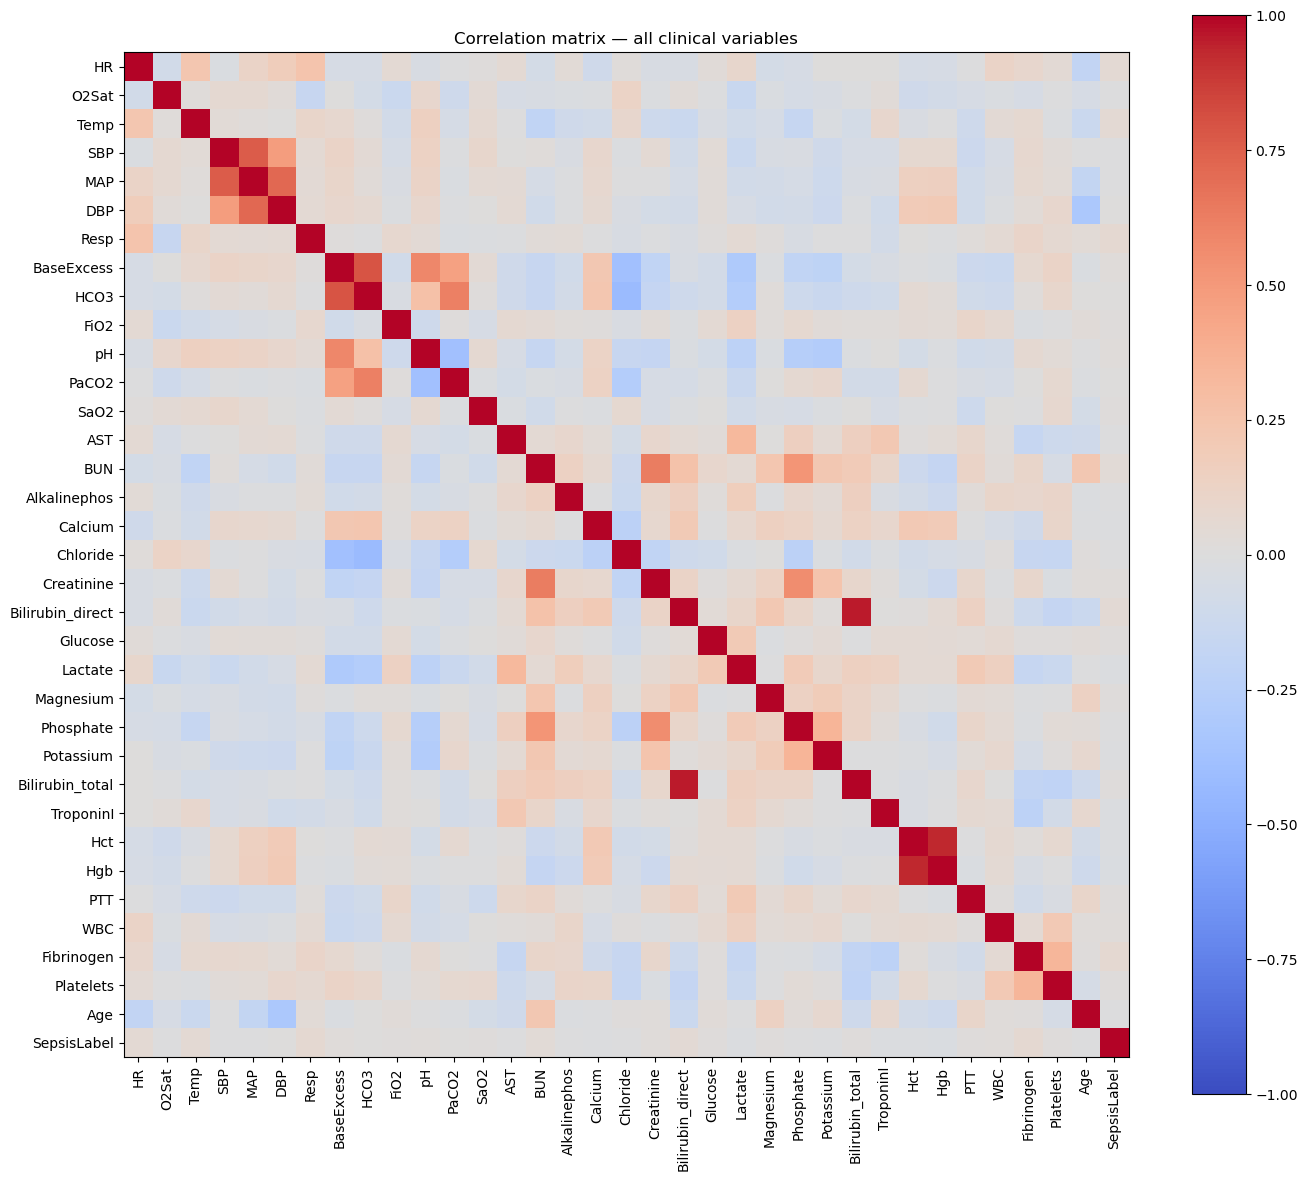

In [12]:
clinical_vars = [c for c in df.columns if c not in ("PatientID", "SepsisLabel", "Gender", "Unit1", "Unit2", "HospAdmTime", "ICULOS")] 

summary_by_class = df.groupby("SepsisLabel")[clinical_vars].mean().T 
summary_by_class.columns = ["No Sepsis", "Sepsis"] 
summary_by_class["difference"] = summary_by_class["Sepsis"] - summary_by_class["No Sepsis"] 

print(summary_by_class.sort_values("difference", key=abs, ascending=False)) 

corr = df[clinical_vars + ["SepsisLabel"]].corr() 

plt.figure(figsize=(14, 12)) 
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1) 
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90) 
plt.yticks(range(len(corr.columns)), corr.columns) 
plt.colorbar() 
plt.title("Correlation matrix — all clinical variables") 
plt.tight_layout() 
plt.show() 

## Descriptive statistics

The code cell uses descriptive statistics to find the standard deviation, IQR, range, skew, meana nd median for each clinical variable.

In [13]:
desc = df[clinical_vars].describe(percentiles=[.25, .5, .75]).T
desc["IQR"] = desc["75%"] - desc["25%"]
desc["skew"] = df[clinical_vars].skew()
print(desc[["mean", "50%", "std", "IQR", "min", "max", "skew"]].round(2))

                    mean     50%     std     IQR    min      max   skew
HR                 84.89   84.00   17.01   23.00  20.00   280.00   0.41
O2Sat              97.22   98.00    2.96    3.00  50.00   100.00  -3.82
Temp               36.94   36.94    0.74    0.95  26.60    42.22  -0.16
SBP               120.87  119.00   21.65   29.50  40.00   281.00   0.51
MAP                78.85   77.00   14.93   19.67  20.00   250.00   0.82
DBP                60.61   59.00   13.26   16.00  20.00   196.00   1.11
Resp               18.79   18.00    5.38    7.00   4.00    60.00   0.86
BaseExcess         -0.02    0.00    4.00    4.00 -32.00   100.00   0.18
HCO3               24.38   24.00    4.21    5.00   0.00    55.00   0.40
FiO2                0.50    0.50    0.19    0.10   0.00    10.00  10.64
pH                  7.39    7.40    0.06    0.07   6.62     7.93  -0.99
PaCO2              40.83   40.00    8.31    9.00  10.00   100.00   1.49
SaO2               91.18   97.00   12.10    5.00  24.00   100.00

## Standardised effect size

The code cell uses standardised difference (Cohen's d) instead of a raw difference to rank variables according to how well they divide two classes. 

In [14]:
grouped = df.groupby("SepsisLabel")[clinical_vars]
summary = grouped.agg(["mean", "median", "std"]).T

# Standardised difference 

means = grouped.mean()
stds  = grouped.std()
pooled = ((stds.loc[0]**2 + stds.loc[1]**2) / 2) ** 0.5
effect = ((means.loc[1] - means.loc[0]) / pooled).abs().sort_values(ascending=False)
print(effect.round(3))

Resp                0.350
HR                  0.314
Fibrinogen          0.284
Temp                0.283
BUN                 0.242
Hgb                 0.178
Bilirubin_direct    0.175
TroponinI           0.146
Creatinine          0.145
WBC                 0.137
BaseExcess          0.134
Hct                 0.132
pH                  0.106
Potassium           0.099
FiO2                0.092
Lactate             0.091
Glucose             0.082
Calcium             0.075
Platelets           0.067
Bilirubin_total     0.062
SaO2                0.059
Magnesium           0.053
PTT                 0.052
O2Sat               0.050
MAP                 0.034
DBP                 0.033
AST                 0.031
PaCO2               0.029
SBP                 0.025
HCO3                0.021
Alkalinephos        0.019
Age                 0.015
Chloride            0.014
Phosphate           0.005
dtype: float64


## Patient level sepsis distribution

A patient is considered to have sepsis if their diagnosis is positive for any of their hours. The graph is a visual representation of patients found with sepsis versus no sepsis. 

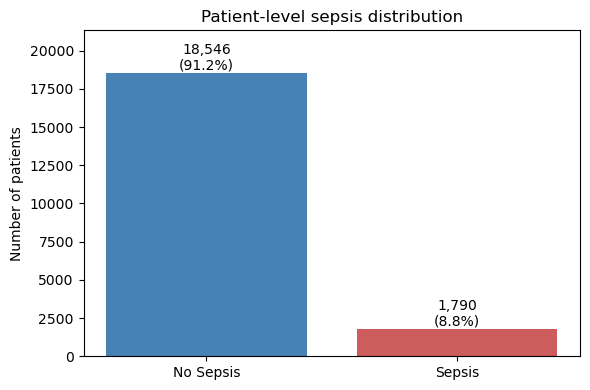

In [15]:
sepsis_counts = df.groupby("PatientID")["SepsisLabel"].max().value_counts().sort_index()

plt.figure(figsize=(6, 4))
bars = plt.bar(["No Sepsis", "Sepsis"], sepsis_counts.values,
               color=["steelblue", "indianred"])

total = sepsis_counts.sum()
for bar, count in zip(bars, sepsis_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, count,
             f"{count:,}\n({count/total:.1%})",
             ha="center", va="bottom", fontsize=10)

plt.ylabel("Number of patients")
plt.title("Patient-level sepsis distribution")
plt.ylim(0, sepsis_counts.max() * 1.15)   
plt.tight_layout()
plt.show()

## Strandardised distribution

This code cell is visualisation of the model standardising variables to identify outliers and assess spread. As the XGBoost model is a scale invariant, it does not require the features scale.

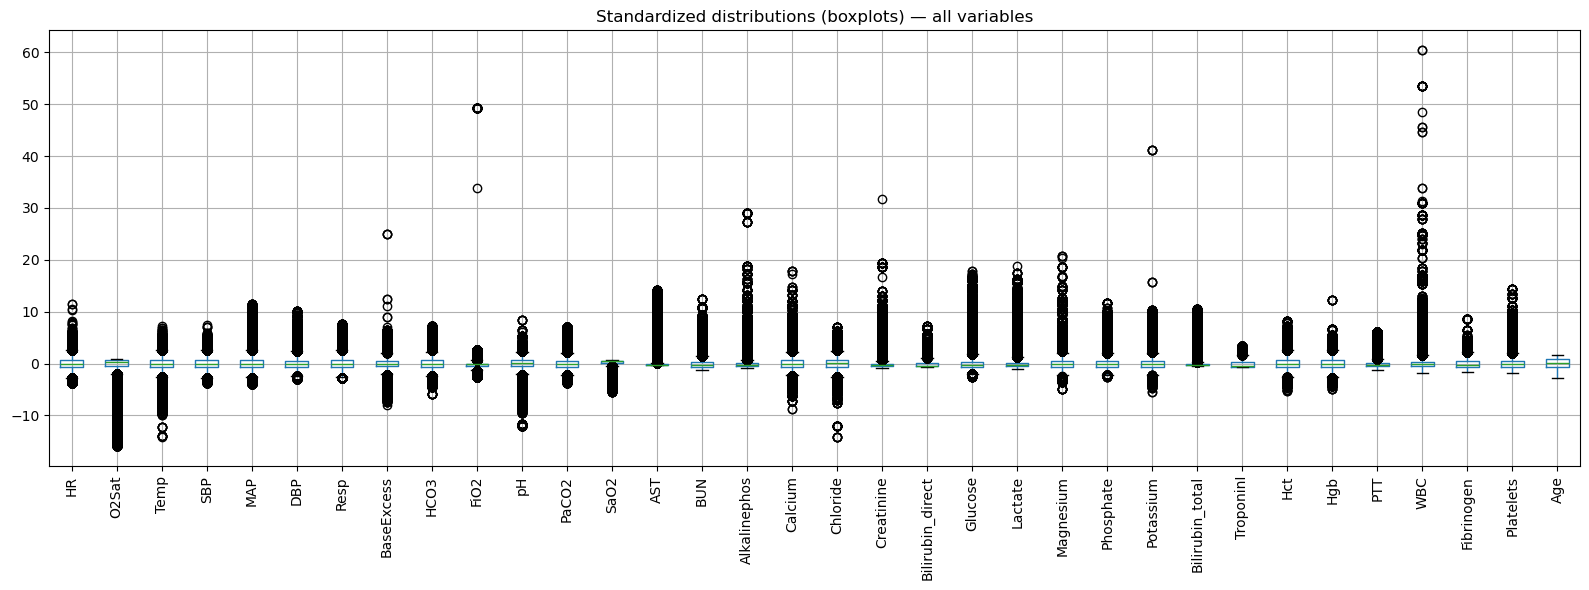

In [16]:
scaled = pd.DataFrame(StandardScaler().fit_transform(df[clinical_vars]), columns=clinical_vars) 

plt.figure(figsize=(16, 6)) 
scaled.boxplot(rot=90) 
plt.title("Standardized distributions (boxplots) — all variables") 
plt.tight_layout() 
plt.show() 

## Data splitting 70/15/15

This code cell is crucial for model development as it splits the clean data into train 70%, test 15% and validation 15%. This step prevents leakage by ensuring no patients data appears in multiple sets, which is evident in the patients overlap output. The positive rate shows that the stratification step above worked correctly and all set are evenly represented. 

In [17]:
# Data Splitting (70/15/15)
feature_cols = [c for c in df.columns if c not in ("PatientID", "SepsisLabel")]
X = df[feature_cols]
y = df["SepsisLabel"].astype(int)
groups = df["PatientID"]

sgkf = StratifiedGroupKFold(n_splits=20, shuffle=True, random_state=42)
folds = list(sgkf.split(X, y, groups))

test_idx  = np.concatenate([folds[i][1] for i in (0, 1, 2)])     
val_idx   = np.concatenate([folds[i][1] for i in (3, 4, 5)])     
train_idx = np.concatenate([folds[i][1] for i in range(6, 20)])  

X_train, y_train = X.iloc[train_idx].copy(), y.iloc[train_idx]
X_val,   y_val   = X.iloc[val_idx].copy(),   y.iloc[val_idx]
X_test,  y_test  = X.iloc[test_idx].copy(),  y.iloc[test_idx]

g_train = groups.iloc[train_idx]  

tr, va, te = set(g_train), set(groups.iloc[val_idx]), set(groups.iloc[test_idx])
print("Patient overlaps (must all be 0):", len(tr & va), len(tr & te), len(va & te))
total = len(X)
print(f"Split sizes -> train {len(X_train):,} ({len(X_train)/total:.1%}), "
      f"val {len(X_val):,} ({len(X_val)/total:.1%}), "
      f"test {len(X_test):,} ({len(X_test)/total:.1%})")
print(f"Positive rate -> train {y_train.mean():.3%}, "
      f"val {y_val.mean():.3%}, test {y_test.mean():.3%}")

Patient overlaps (must all be 0): 0 0 0
Split sizes -> train 553,286 (70.0%), val 118,448 (15.0%), test 118,481 (15.0%)
Positive rate -> train 2.169%, val 2.167%, test 2.167%


## Preprocessing (training only)

This code cell uses the median learned from the training set solely and fills in the remaining missing values left after cleaning. 

In [18]:
# Remaining NaNs filled

value_cols = [c for c in feature_cols]


train_median = X_train[value_cols].median(numeric_only=True)

X_train[value_cols] = X_train[value_cols].fillna(train_median)
X_val[value_cols]   = X_val[value_cols].fillna(train_median)    
X_test[value_cols]  = X_test[value_cols].fillna(train_median)   

print("Missing after impute -> "
      f"train {X_train.isna().sum().sum()}, "
      f"val {X_val.isna().sum().sum()}, "
      f"test {X_test.isna().sum().sum()}  (all must be 0)")

Missing after impute -> train 0, val 0, test 0  (all must be 0)


## Feature engineering

This code cells uses _delta to capture changes from the prior hours and _roll6 for the 6 hour rolling mean. Features use backward looking  per patient to ensure patient's future data is not used, which is in line with our early warning approach.

In [19]:
# Feature Engineering using backward-looking only

core_vars = [c for c in ["HR","O2Sat","Temp","SBP","MAP","DBP",
                         "Resp","Lactate","WBC","Creatinine"] if c in value_cols]

def add_temporal_features(Xpart, ids):
    """Add _delta and _roll6 per patient using only current + past hours."""
    part = Xpart.copy()
    part["_pid"] = ids.values
    g = part.groupby("_pid", sort=False)
    for col in core_vars:
        part[f"{col}_delta"] = g[col].diff()                                    
        part[f"{col}_roll6"] = g[col].transform(lambda s: s.rolling(6, min_periods=1).mean())  
    delta_cols = [f"{c}_delta" for c in core_vars]
    part[delta_cols] = part.groupby("_pid", sort=False)[delta_cols].transform(lambda s: s.fillna(0.0))
    return part.drop(columns="_pid")

X_train = add_temporal_features(X_train, g_train)
X_val   = add_temporal_features(X_val,   groups.iloc[val_idx])
X_test  = add_temporal_features(X_test,  groups.iloc[test_idx])

feature_cols = list(X_train.columns)
print(f"Feature count after engineering: {len(feature_cols)} "
      f"({len(core_vars)} delta + {len(core_vars)} roll6 added)")
print("Remaining NaNs:", X_train.isna().sum().sum(), X_val.isna().sum().sum(), X_test.isna().sum().sum())

Feature count after engineering: 59 (10 delta + 10 roll6 added)
Remaining NaNs: 0 0 0


## Model Development — XGBoost with imbalance handling and early stopping

This code cell tackles the risk of overfitting and the class imbalance by training the gradient boost classifier. Additionally positive classes are reweighted, features are subsampled and early stopping is applied to validation AUC to choose the value of trees.

In [20]:
# Imbalance handling and early stopping

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {scale_pos_weight:.1f}")

model = xgb.XGBClassifier(
    objective="binary:logistic",
    tree_method="hist",
    n_estimators=1000,          
    learning_rate=0.05,         
    max_depth=6,                
    subsample=0.8,              
    colsample_bytree=0.8,       
    min_child_weight=1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",        
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

print(f"Best iteration (trees kept): {model.best_iteration}")
print(f"Validation AUPRC: {average_precision_score(y_val, model.predict_proba(X_val)[:,1]):.3f}")

scale_pos_weight = 45.1
Best iteration (trees kept): 83
Validation AUPRC: 0.113


## Threshold selection

This code cell determines the F1 score at each candidate threshold, computes the precision–recall curve on the validation set, and selects the candidate that maximises F1. The threshold is selected based on validation as opposed to test results.

In [21]:
# Threshold Decision on the validation set

val_proba = model.predict_proba(X_val)[:, 1]
prec, rec, thr = precision_recall_curve(y_val, val_proba)
f1_scores = 2 * prec * rec / (prec + rec + 1e-9)

best_i = np.argmax(f1_scores[:-1])     
best_threshold = thr[best_i]

print(f"Best threshold (max F1 on validation): {best_threshold:.3f}")
print(f"Validation F1 at this threshold: {f1_scores[best_i]:.3f}")

Best threshold (max F1 on validation): 0.705
Validation F1 at this threshold: 0.189


## Evaluation

The evaluation code cell applies the chosen threshold to turn probabilities into predictions. Also this cell measures the trained model by using AUPRC, AUROC, F1, precision, recall and accuracy. The three graphs below contain the confusion matrix, the AUROC curve and the precision recall curve.

Test AUPRC: 0.107  |  Test AUROC: 0.804
F1: 0.183  Precision: 0.123  Recall: 0.353  Accuracy: 0.931


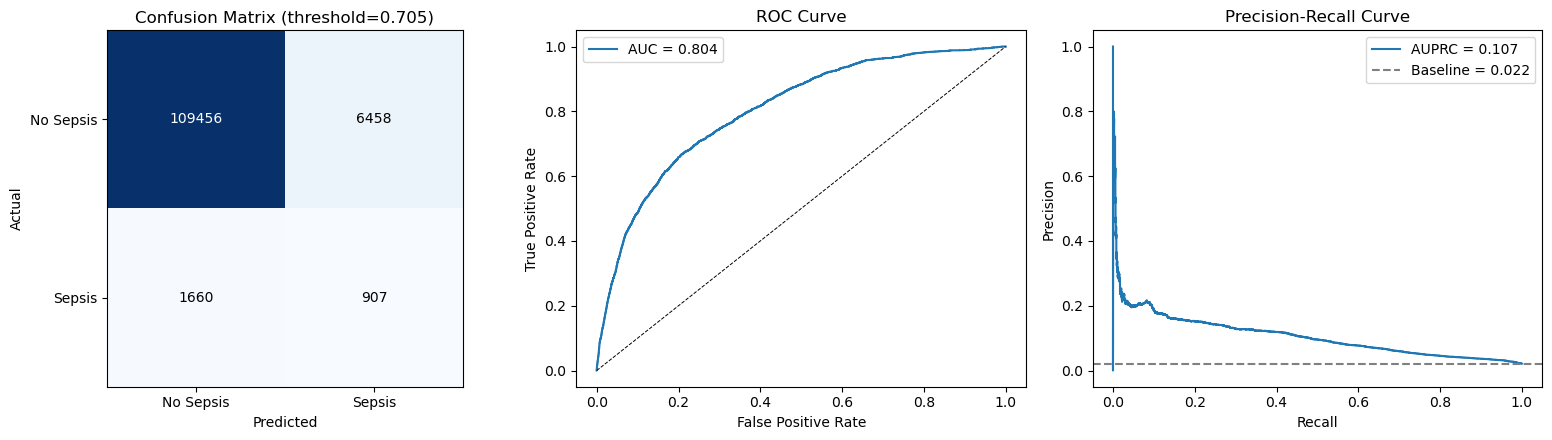

In [22]:
# Confusion matrix, ROC curve, and PR curve 

test_proba = model.predict_proba(X_test)[:, 1]
test_pred  = (test_proba >= best_threshold).astype(int)   # threshold from CELL 5

auprc = average_precision_score(y_test, test_proba)
auroc = roc_auc_score(y_test, test_proba)
print(f"Test AUPRC: {auprc:.3f}  |  Test AUROC: {auroc:.3f}")
print(f"F1: {f1_score(y_test, test_pred):.3f}  "
      f"Precision: {precision_score(y_test, test_pred):.3f}  "
      f"Recall: {recall_score(y_test, test_pred):.3f}  "
      f"Accuracy: {accuracy_score(y_test, test_pred):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

cm = confusion_matrix(y_test, test_pred)
axes[0].imshow(cm, cmap="Blues")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["No Sepsis", "Sepsis"])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["No Sepsis", "Sepsis"])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
axes[0].set_title(f"Confusion Matrix (threshold={best_threshold:.3f})")
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max()/2 else "black")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, test_proba)
axes[1].plot(fpr, tpr, label=f"AUC = {auroc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=0.7)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve"); axes[1].legend()

# Precision-Recall curve
prec_c, rec_c, _ = precision_recall_curve(y_test, test_proba)
axes[2].plot(rec_c, prec_c, label=f"AUPRC = {auprc:.3f}")
axes[2].axhline(y_test.mean(), color="grey", linestyle="--",
                label=f"Baseline = {y_test.mean():.3f}")
axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve"); axes[2].legend()

plt.tight_layout(); plt.show()

## Clinical Metric: Average Lead Time Before Diagnosis

The following code cell measures the first hour the model generates an alert for every patient in the test data who is labeled positive for sepsis and actually septic. The diagram below is the distribution of additional lead time among patient identified by the model.

Septic patients in test set: 269
Caught at or before the label: 112 (41.6%)
Mean extra lead time before the shifted label: 51.91 hours
=> Mean total warning before true clinical onset: 57.91 hours


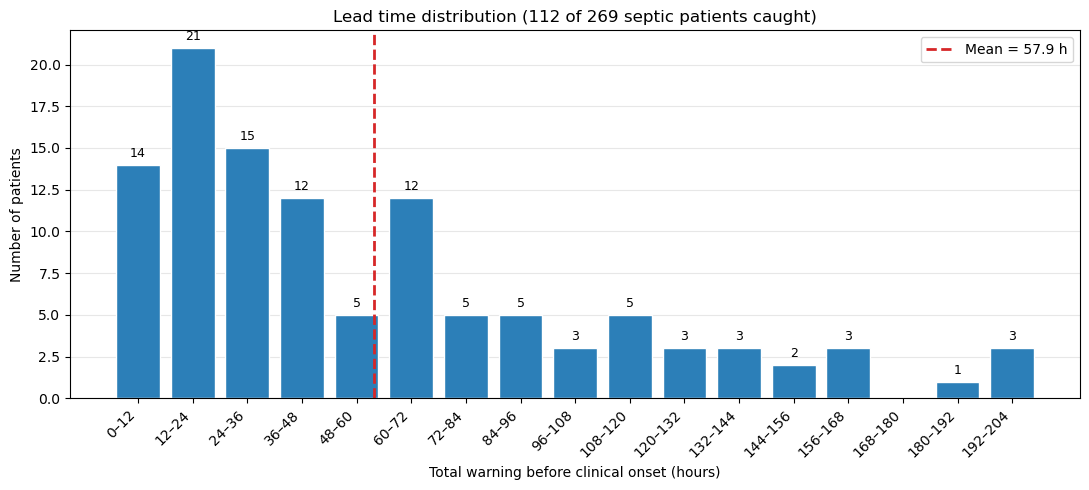

In [23]:
# Average Lead Time Before Diagnosis

test_meta = df.iloc[test_idx][["PatientID", "ICULOS", "SepsisLabel"]].copy()
test_meta["pred"] = (model.predict_proba(X_test)[:, 1] >= best_threshold).astype(int)

lead_times = []
n_septic = 0
for pid, grp in test_meta.groupby("PatientID"):
    grp = grp.sort_values("ICULOS")
    if grp["SepsisLabel"].max() == 1:                                  
        n_septic += 1
        label_hour = grp.loc[grp["SepsisLabel"] == 1, "ICULOS"].min()  
        fired = grp.loc[grp["pred"] == 1, "ICULOS"]
        if len(fired) > 0 and fired.min() <= label_hour:               
            lead_times.append(label_hour - fired.min())                

n_caught = len(lead_times)
print(f"Septic patients in test set: {n_septic}")
print(f"Caught at or before the label: {n_caught} ({n_caught/n_septic:.1%})")
if n_caught:
    mean_extra = np.mean(lead_times)
    print(f"Mean extra lead time before the shifted label: {mean_extra:.2f} hours")
    print(f"=> Mean total warning before true clinical onset: {mean_extra + 6:.2f} hours")


# Visualise the distribution of the lead time

import matplotlib.pyplot as plt

if n_caught:
    total = np.array(lead_times) + 6
    bin_width = 12

    bins = np.arange(0, total.max() + bin_width, bin_width)
    counts, edges = np.histogram(total, bins=bins)
    labels = [f"{int(edges[i])}–{int(edges[i+1])}" for i in range(len(counts))]

    fig, ax = plt.subplots(figsize=(11, 5))
    bars = ax.bar(labels, counts, color="#2c7fb8", edgecolor="white", width=0.8)

    for bar, c in zip(bars, counts):
        if c > 0:
            ax.text(bar.get_x() + bar.get_width()/2, c + 0.3, str(c),
                    ha="center", va="bottom", fontsize=9)

    mean_total = mean_extra + 6
    mean_pos = mean_total / bin_width - 0.5      
    ax.axvline(mean_pos, color="#d62728", linestyle="--", linewidth=2,
               label=f"Mean = {mean_total:.1f} h")

    ax.set_xlabel("Total warning before clinical onset (hours)")
    ax.set_ylabel("Number of patients")
    ax.set_title(f"Lead time distribution ({n_caught} of {n_septic} septic patients caught)")
    ax.legend()
    plt.xticks(rotation=45, ha="right")
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

In [24]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable


## Explainable AI (XAI) with SHAP

The explainable AI tool SHAP has been applied to understand which features influence the model's prediction. 

/opt/conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


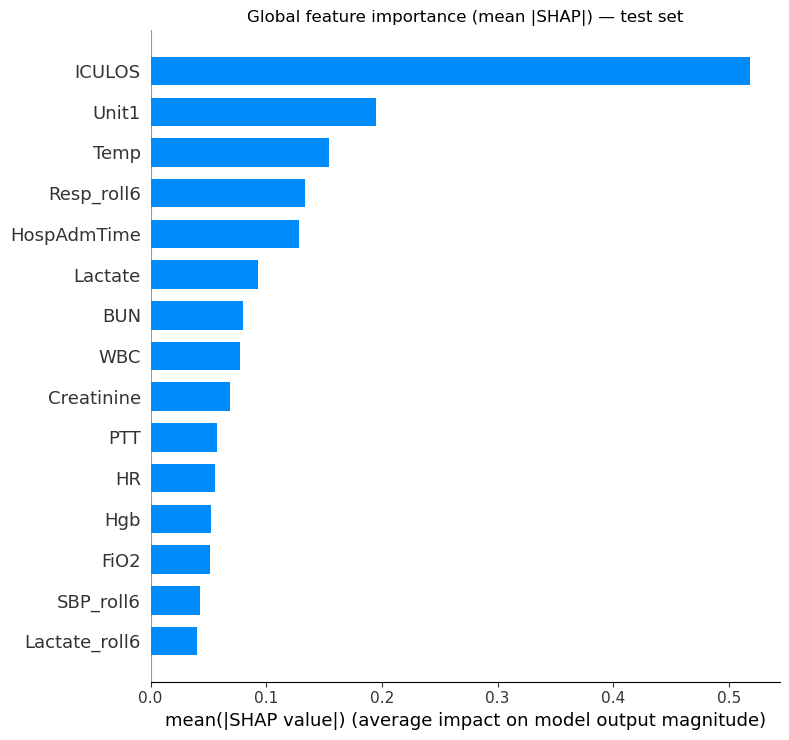

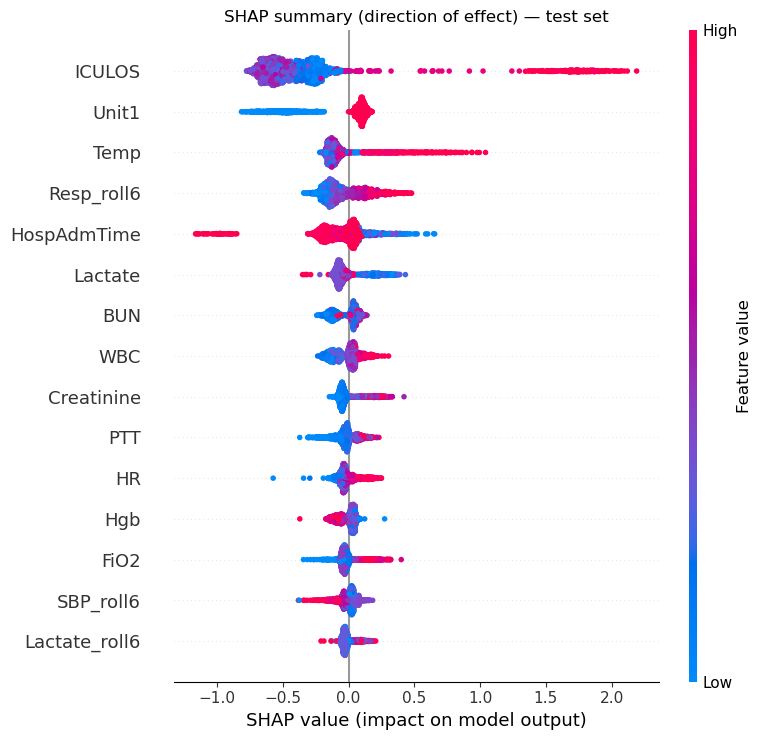

In [25]:
# SHAP
import shap
import numpy as np
import matplotlib.pyplot as plt


sample_n = min(2000, len(X_test))
X_shap = X_test.sample(n=sample_n, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False, max_display=15)
plt.title("Global feature importance (mean |SHAP|) — test set")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_shap, show=False, max_display=15)
plt.title("SHAP summary (direction of effect) — test set")
plt.tight_layout()
plt.show()